In [11]:
print("Task 1")
print("1. Read and Summarize the Data")
print('')

import pandas as pd

# 1. Read the CSV file into a DataFrame named df_raw
df_raw = pd.read_csv("ims_setup_project02.csv")

# 2. Display basic information about the raw DataFrame

print("First five rows:")
display(df_raw.head())

print("\nNumber of rows and columns:")
print(df_raw.shape)

print("\nColumn names:")
print(df_raw.columns.tolist())

print("\nDescriptive statistics:")
display(df_raw.describe(include="all"))

print("\nMissing values in each column:")
print(df_raw.isna().sum())

# 3. Create cleaned DataFrame named df

required_columns = [
    "lap",
    "rear_wing_angle_deg",
    "rear_ride_height_mm",
    "sector_3_time_s",
    "top_speed_kph"
]

df = df_raw[required_columns].copy()

for column in required_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

df = df.drop_duplicates()

df = df.dropna(subset=required_columns)

print("\nCleaned DataFrame:")
display(df.head())

print("\nCleaned DataFrame shape:")
print(df.shape)

print('')
print('2. Create the setup-level DataFrame')
print('')

# 4-5. Group by setup and calculate summary statistics

df_grouped = (
    df.groupby(
        ["rear_wing_angle_deg", "rear_ride_height_mm"]
    )
    .agg(
        mean_sector_3_time_s=("sector_3_time_s", "mean"),
        std_sector_3_time_s=("sector_3_time_s", "std"),
        mean_top_speed_kph=("top_speed_kph", "mean"),
        std_top_speed_kph=("top_speed_kph", "std"),
        valid_laps=("lap", "count")
    )
    .reset_index()
)

# 6. Display results and report number of unique setups

print("Grouped setup results:")
display(df_grouped)

num_unique_setups = len(df_grouped)

print("\nNumber of unique setup configurations:")
print(num_unique_setups)

df_grouped.to_csv(
    "Aramthun_pr02_grouped.csv",
    index=False
)

print("\nFile saved as: Aramthun_pr02_grouped.csv")

Task 1
1. Read and Summarize the Data

First five rows:


,lap,rear_wing_angle_deg,rear_ride_height_mm,sector_3_time_s,top_speed_kph
0,1,5,35,33.0949,286.761
1,2,5,35,32.9325,287.079
2,3,5,35,33.0858,287.261
3,4,5,35,33.0472,287.059
4,5,5,35,33.0534,287.463



Number of rows and columns:
(135, 5)

Column names:
['lap', 'rear_wing_angle_deg', 'rear_ride_height_mm', 'sector_3_time_s', 'top_speed_kph']

Descriptive statistics:


,lap,rear_wing_angle_deg,rear_ride_height_mm,sector_3_time_s,top_speed_kph
count,135.000000,135.000000,135.000000,135.000000,135.000000
mean,3.000000,9.000000,40.000000,31.803734,284.178563
std,1.419481,2.591605,4.097688,0.542766,1.778668
min,1.000000,5.000000,35.000000,31.061300,280.887000
25%,2.000000,7.000000,35.000000,31.413650,282.690500
50%,3.000000,9.000000,40.000000,31.599500,284.373000
75%,4.000000,11.000000,45.000000,32.041350,285.638000
max,5.000000,13.000000,45.000000,33.094900,287.463000



Missing values in each column:
lap                    0
rear_wing_angle_deg    0
rear_ride_height_mm    0
sector_3_time_s        0
top_speed_kph          0
dtype: int64

Cleaned DataFrame:


,lap,rear_wing_angle_deg,rear_ride_height_mm,sector_3_time_s,top_speed_kph
0,1,5,35,33.0949,286.761
1,2,5,35,32.9325,287.079
2,3,5,35,33.0858,287.261
3,4,5,35,33.0472,287.059
4,5,5,35,33.0534,287.463



Cleaned DataFrame shape:
(135, 5)

2. Create the setup-level DataFrame

Grouped setup results:


,rear_wing_angle_deg,rear_ride_height_mm,mean_sector_3_time_s,std_sector_3_time_s,mean_top_speed_kph,std_top_speed_kph,valid_laps
0,5,35,33.04276,0.064925,287.1246,0.260628,5
1,5,40,32.85104,0.104126,286.7078,0.260848,5
2,5,45,32.99286,0.022043,286.6164,0.061272,5
3,6,35,32.51308,0.053101,286.5346,0.172712,5
4,6,40,32.38096,0.050323,286.2574,0.229553,5
5,6,45,32.44690,0.077138,285.7634,0.171296,5
6,7,35,32.03248,0.035651,285.8530,0.289042,5
7,7,40,31.86244,0.059775,285.3564,0.242663,5
8,7,45,32.01484,0.053106,285.0412,0.182341,5
9,8,35,31.68490,0.054910,285.3770,0.150690,5



Number of unique setup configurations:
27

File saved as: Aramthun_pr02_grouped.csv


Task #2
1. Training and Test Configurations
Number of training configurations:
20

Number of test configurations:
7

2. Quadratic response surfaces

Sector 3 Time Coefficient Vector:
[ 4.73886880e+01 -1.29838222e+00 -4.80678309e-01  5.43427458e-02
  5.67136642e-03  3.88185285e-03]

Top Speed Coefficient Vector:
[ 2.95038265e+02 -5.55986025e-01 -2.02484393e-01 -7.21976597e-03
  1.70273178e-03  3.35132466e-04]

Fitted Sector 3 Time Equation:
ŷ_time = 47.388688 + (-1.298382)x1 + (-0.480678)x2 + (0.054343)x1^2 + (0.005671)x2^2 + (0.003882)x1x2

Fitted Top Speed Equation:
ŷ_speed = 295.038265 + (-0.555986)x1 + (-0.202484)x2 + (-0.007220)x1^2 + (0.001703)x2^2 + (0.000335)x1x2

3. Validation and final surrogate models

Test-set predictions:


,rear_wing_angle_deg,rear_ride_height_mm,mean_sector_3_time_s,mean_top_speed_kph,predicted_sector_3_time_s,predicted_top_speed_kph
8,7,45,32.01484,285.0412,32.039584,285.234395
13,9,40,31.34738,284.4520,31.349531,284.195233
9,8,35,31.68490,285.3770,31.690168,285.221042
21,12,35,31.41880,282.3054,31.387518,282.466435
0,5,35,33.04276,287.1246,33.058353,287.135382
11,8,45,31.73018,284.4710,31.731026,284.585194
16,10,40,31.18592,283.6652,31.238935,283.515477



Validation results:


,response,RMSE,R2
0,mean_sector_3_time_s,0.025850,0.997994
1,mean_top_speed_kph,0.164353,0.985828


Saved: Aramthun_pr02_validation.csv


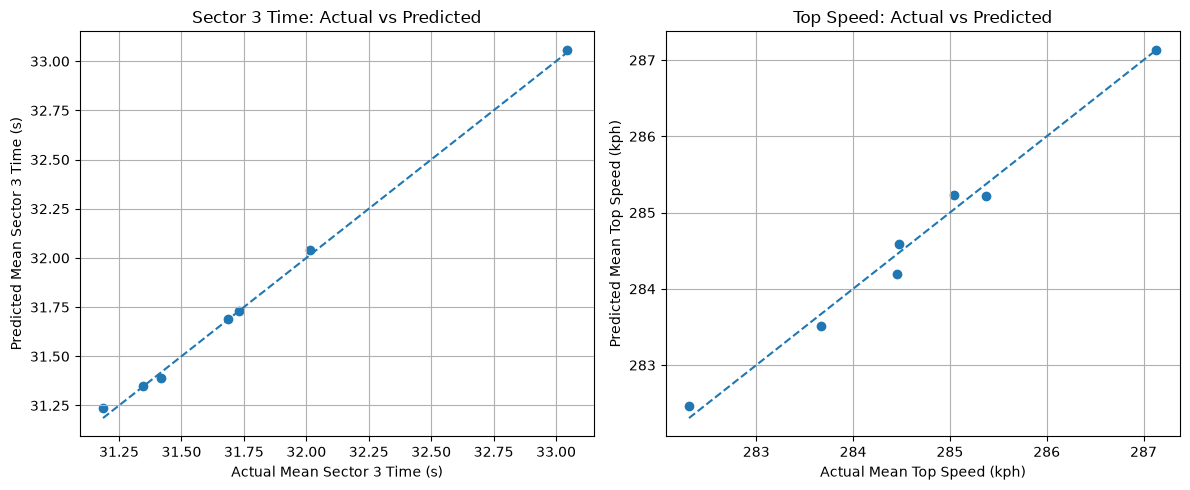

Saved: Aramthun_pr02_validation.png

Final Sector 3 Time Coefficients:
[ 4.76898783e+01 -1.29676876e+00 -4.96329400e-01  5.47137951e-02
  5.88284444e-03  3.69660000e-03]

Final Top Speed Coefficients:
[ 2.91606388e+02 -5.75056696e-01 -2.01751111e-02 -1.02046898e-02
 -8.22222222e-04  2.16266667e-03]

Example configuration:
Rear wing angle = 5.0 deg, Rear ride height = 35.0 mm
Predicted Sector 3 time = 33.0557 s
Predicted top speed = 287.1411 kph


In [23]:
print('Task #2')
print('1. Training and Test Configurations')

from sklearn.model_selection import train_test_split

# 7. Split grouped setup data into training and test sets

df_train, df_test = train_test_split(
    df_grouped,
    test_size=0.25,
    random_state=42
)

# 8. Display number of training and test configurations

print("Number of training configurations:")
print(len(df_train))

print("\nNumber of test configurations:")
print(len(df_test))

print('')
print('2. Quadratic response surfaces')
print('')

import numpy as np

# 9. Create the quadratic design matrix

def create_design_matrix(x1, x2):
    x1 = np.asarray(x1, dtype=float)
    x2 = np.asarray(x2, dtype=float)

    X = np.column_stack([
        np.ones(len(x1)),   # 1
        x1,                 # x1
        x2,                 # x2
        x1**2,              # x1^2
        x2**2,              # x2^2
        x1 * x2             # x1*x2
    ])

    return X


# 10. Fit quadratic model for mean Sector 3 time

x1_train = df_train["rear_wing_angle_deg"].to_numpy()
x2_train = df_train["rear_ride_height_mm"].to_numpy()

X_train = create_design_matrix(x1_train, x2_train)

y_time_train = df_train["mean_sector_3_time_s"].to_numpy()

# Moore-Penrose pseudoinverse
b_time_train = np.linalg.pinv(X_train) @ y_time_train

# 11. Fit quadratic model for mean top speed

y_speed_train = df_train["mean_top_speed_kph"].to_numpy()

b_speed_train = np.linalg.pinv(X_train) @ y_speed_train

# 12. Display coefficient vectors and fitted equations

print("Sector 3 Time Coefficient Vector:")
print(b_time_train)

print("\nTop Speed Coefficient Vector:")
print(b_speed_train)


print("\nFitted Sector 3 Time Equation:")
print(
    f"ŷ_time = {b_time_train[0]:.6f} "
    f"+ ({b_time_train[1]:.6f})x1 "
    f"+ ({b_time_train[2]:.6f})x2 "
    f"+ ({b_time_train[3]:.6f})x1^2 "
    f"+ ({b_time_train[4]:.6f})x2^2 "
    f"+ ({b_time_train[5]:.6f})x1x2"
)

print("\nFitted Top Speed Equation:")
print(
    f"ŷ_speed = {b_speed_train[0]:.6f} "
    f"+ ({b_speed_train[1]:.6f})x1 "
    f"+ ({b_speed_train[2]:.6f})x2 "
    f"+ ({b_speed_train[3]:.6f})x1^2 "
    f"+ ({b_speed_train[4]:.6f})x2^2 "
    f"+ ({b_speed_train[5]:.6f})x1x2"
)

print('')
print('3. Validation and final surrogate models')
print('')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# 13. Predict mean Sector 3 time and mean top speed
#     for the unseen test configurations

x1_test = df_test["rear_wing_angle_deg"].to_numpy()
x2_test = df_test["rear_ride_height_mm"].to_numpy()

X_test = create_design_matrix(x1_test, x2_test)

y_time_test = df_test["mean_sector_3_time_s"].to_numpy()
y_speed_test = df_test["mean_top_speed_kph"].to_numpy()

y_time_pred = X_test @ b_time_train
y_speed_pred = X_test @ b_speed_train

df_test_predictions = df_test[
    [
        "rear_wing_angle_deg",
        "rear_ride_height_mm",
        "mean_sector_3_time_s",
        "mean_top_speed_kph"
    ]
].copy()

df_test_predictions["predicted_sector_3_time_s"] = y_time_pred
df_test_predictions["predicted_top_speed_kph"] = y_speed_pred

print("Test-set predictions:")
display(df_test_predictions)

# 14. Calculate test-set RMSE and R^2

rmse_time = np.sqrt(mean_squared_error(y_time_test, y_time_pred))
r2_time = r2_score(y_time_test, y_time_pred)

rmse_speed = np.sqrt(mean_squared_error(y_speed_test, y_speed_pred))
r2_speed = r2_score(y_speed_test, y_speed_pred)

df_validation = pd.DataFrame({
    "response": [
        "mean_sector_3_time_s",
        "mean_top_speed_kph"
    ],
    "RMSE": [
        rmse_time,
        rmse_speed
    ],
    "R2": [
        r2_time,
        r2_speed
    ]
})

print("\nValidation results:")
display(df_validation)

df_validation.to_csv(
    "Aramthun_pr02_validation.csv",
    index=False
)

print("Saved: Aramthun_pr02_validation.csv")

# 15. Actual-versus-predicted validation plots

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_time_test, y_time_pred)

time_min = min(y_time_test.min(), y_time_pred.min())
time_max = max(y_time_test.max(), y_time_pred.max())

axes[0].plot(
    [time_min, time_max],
    [time_min, time_max],
    "--"
)

axes[0].set_xlabel("Actual Mean Sector 3 Time (s)")
axes[0].set_ylabel("Predicted Mean Sector 3 Time (s)")
axes[0].set_title("Sector 3 Time: Actual vs Predicted")
axes[0].grid(True)

axes[1].scatter(y_speed_test, y_speed_pred)

speed_min = min(y_speed_test.min(), y_speed_pred.min())
speed_max = max(y_speed_test.max(), y_speed_pred.max())

axes[1].plot(
    [speed_min, speed_max],
    [speed_min, speed_max],
    "--"
)

axes[1].set_xlabel("Actual Mean Top Speed (kph)")
axes[1].set_ylabel("Predicted Mean Top Speed (kph)")
axes[1].set_title("Top Speed: Actual vs Predicted")
axes[1].grid(True)


plt.tight_layout()

plt.savefig(
    "Aramthun_pr02_validation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: Aramthun_pr02_validation.png")


# 17. Refit both quadratic models using ALL configurations

x1_all = df_grouped["rear_wing_angle_deg"].to_numpy()
x2_all = df_grouped["rear_ride_height_mm"].to_numpy()

X_all = create_design_matrix(x1_all, x2_all)

y_time_all = df_grouped["mean_sector_3_time_s"].to_numpy()
y_speed_all = df_grouped["mean_top_speed_kph"].to_numpy()

b_time = np.linalg.pinv(X_all) @ y_time_all

b_speed = np.linalg.pinv(X_all) @ y_speed_all


print("\nFinal Sector 3 Time Coefficients:")
print(b_time)

print("\nFinal Top Speed Coefficients:")
print(b_speed)

# 18. Define prediction functions

def predict_sector_time(x):
    x = np.asarray(x, dtype=float)

    design_row = np.array([
        1.0,
        x[0],
        x[1],
        x[0]**2,
        x[1]**2,
        x[0] * x[1]
    ])

    return float(design_row @ b_time)


def predict_top_speed(x):
    x = np.asarray(x, dtype=float)

    design_row = np.array([
        1.0,
        x[0],
        x[1],
        x[0]**2,
        x[1]**2,
        x[0] * x[1]
    ])

    return float(design_row @ b_speed)


x_example = df_grouped[
    ["rear_wing_angle_deg", "rear_ride_height_mm"]
].iloc[0].to_numpy(dtype=float)

print("\nExample configuration:")
print(
    f"Rear wing angle = {x_example[0]:.1f} deg, "
    f"Rear ride height = {x_example[1]:.1f} mm"
)

print(
    f"Predicted Sector 3 time = "
    f"{predict_sector_time(x_example):.4f} s"
)

print(
    f"Predicted top speed = "
    f"{predict_top_speed(x_example):.4f} kph"
)



Task #2 Markdown: 
The quadratic response surfaces appear sufficiently credible for the optimization exercise. On the unseen test configurations, the Sector 3 time model produced an RMSE of approximately 0.0259 s and an R² of approximately 0.9980, indicating excellent predictive performance. The top-speed model produced an RMSE of approximately 0.1644 kph and an R² of approximately 0.9858, which also indicates strong agreement between predicted and actual values. The top-speed model is slightly less accurate than the Sector 3 time model, but both models explain most of the variation in the test data. An important limitation is that the test set contains only a small number of setup configurations, so the validation statistics may be sensitive to the particular train-test split. In addition, the quadratic models should primarily be trusted within the range of rear-wing angles and ride heights that were actually tested, since extrapolation beyond the tested setup range may not accurately represent the true vehicle response.

Task #3
1. Grid-based reference search

Rear wing angle bounds:
(np.int64(5), np.int64(13))

Rear ride height bounds:
(np.int64(35), np.int64(45))

Best Unconstrained Grid Point
--------------------------------
Rear wing angle: 10.52 deg
Rear ride height: 38.90 mm
Predicted Sector 3 time: 31.2106 s
Predicted top speed: 283.2835 kph

2. Numerical optimization with scipy.optimize

Optimization success:
True

Optimization message:
CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL

Recommended Design:
Rear wing angle = 10.5373 deg
Rear ride height = 38.8739 mm

Predicted Sector 3 time = 31.2106 s
Predicted top speed = 283.2729 kph

3. Verification and visualization

Comparison of Grid Search and Numerical Optimizer
-------------------------------------------------

Best Grid Point:
Rear wing angle = 10.5200 deg
Rear ride height = 38.9000 mm
Predicted Sector 3 time = 31.210586 s

Numerical Optimizer Solution:
Rear wing angle = 10.5373 deg
Rear ride height = 38.8739 mm
Predicted Sector 3 time

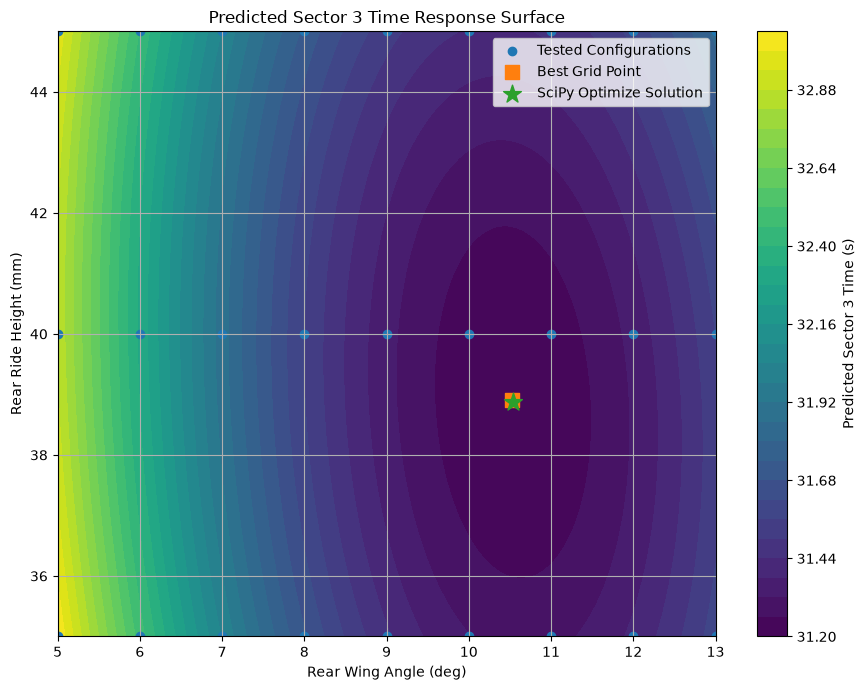


Saved: Aramthun_pr02_unconstrained.png


In [26]:
print('Task #3')
print('1. Grid-based reference search')
print('')

# 19. Define tested bounds from df_grouped

wing_bounds = (
    df_grouped["rear_wing_angle_deg"].min(),
    df_grouped["rear_wing_angle_deg"].max()
)

ride_height_bounds = (
    df_grouped["rear_ride_height_mm"].min(),
    df_grouped["rear_ride_height_mm"].max()
)

print("Rear wing angle bounds:")
print(wing_bounds)

print("\nRear ride height bounds:")
print(ride_height_bounds)

# 20. Create a 101 x 101 design grid and evaluate
#     predicted Sector 3 time at every point

wing_values = np.linspace(
    wing_bounds[0],
    wing_bounds[1],
    101
)

ride_height_values = np.linspace(
    ride_height_bounds[0],
    ride_height_bounds[1],
    101
)

wing_grid, ride_height_grid = np.meshgrid(
    wing_values,
    ride_height_values
)

sector_time_grid = np.empty_like(
    wing_grid,
    dtype=float
)

for i in range(wing_grid.shape[0]):
    for j in range(wing_grid.shape[1]):

        x = np.array([
            wing_grid[i, j],
            ride_height_grid[i, j]
        ])

        sector_time_grid[i, j] = predict_sector_time(x)


# 21. Find the best unconstrained grid point

minimum_sector_time = np.min(sector_time_grid)

minimum_index = np.argmin(sector_time_grid)

row_index, column_index = np.unravel_index(
    minimum_index,
    sector_time_grid.shape
)

best_wing_angle = wing_grid[
    row_index,
    column_index
]

best_ride_height = ride_height_grid[
    row_index,
    column_index
]

best_sector_time = minimum_sector_time

best_top_speed = predict_top_speed(
    np.array([
        best_wing_angle,
        best_ride_height
    ])
)

# Report the best unconstrained configuration

print("\nBest Unconstrained Grid Point")
print("--------------------------------")

print(
    f"Rear wing angle: "
    f"{best_wing_angle:.2f} deg"
)

print(
    f"Rear ride height: "
    f"{best_ride_height:.2f} mm"
)

print(
    f"Predicted Sector 3 time: "
    f"{best_sector_time:.4f} s"
)

print(
    f"Predicted top speed: "
    f"{best_top_speed:.4f} kph"
)

print('')
print('2. Numerical optimization with scipy.optimize')
print('')

import scipy.optimize as opt
import numpy as np

# 22. Define the objective function

def objective(x):
    return predict_sector_time(x)

# 23. Choose an initial design near the center of the
#     tested region and solve the bounds-only problem

x0 = np.array([
    (wing_bounds[0] + wing_bounds[1]) / 2,
    (ride_height_bounds[0] + ride_height_bounds[1]) / 2
])

bounds = [
    wing_bounds,
    ride_height_bounds
]

result_unconstrained = opt.minimize(
    objective,
    x0,
    method="L-BFGS-B",
    bounds=bounds
)

# 24. Report optimization results

recommended_design = result_unconstrained.x

recommended_wing_angle = recommended_design[0]
recommended_ride_height = recommended_design[1]

predicted_sector_time = predict_sector_time(
    recommended_design
)

predicted_top_speed = predict_top_speed(
    recommended_design
)


print("Optimization success:")
print(result_unconstrained.success)

print("\nOptimization message:")
print(result_unconstrained.message)

print("\nRecommended Design:")
print(
    f"Rear wing angle = "
    f"{recommended_wing_angle:.4f} deg"
)

print(
    f"Rear ride height = "
    f"{recommended_ride_height:.4f} mm"
)

print(
    f"\nPredicted Sector 3 time = "
    f"{predicted_sector_time:.4f} s"
)

print(
    f"Predicted top speed = "
    f"{predicted_top_speed:.4f} kph"
)

print('')
print('3. Verification and visualization')
print('')

import numpy as np
import matplotlib.pyplot as plt

# 25. Compare numerical optimizer with best grid point


opt_wing_angle = result_unconstrained.x[0]
opt_ride_height = result_unconstrained.x[1]

wing_grid_resolution = (
    wing_bounds[1] - wing_bounds[0]
) / 100

ride_grid_resolution = (
    ride_height_bounds[1] - ride_height_bounds[0]
) / 100

wing_difference = abs(
    opt_wing_angle - best_wing_angle
)

ride_difference = abs(
    opt_ride_height - best_ride_height
)

opt_sector_time = predict_sector_time(
    result_unconstrained.x
)

time_difference = abs(
    opt_sector_time - best_sector_time
)

agree_within_grid = (
    wing_difference <= wing_grid_resolution
    and
    ride_difference <= ride_grid_resolution
)


print("Comparison of Grid Search and Numerical Optimizer")
print("-------------------------------------------------")

print("\nBest Grid Point:")
print(
    f"Rear wing angle = {best_wing_angle:.4f} deg"
)
print(
    f"Rear ride height = {best_ride_height:.4f} mm"
)
print(
    f"Predicted Sector 3 time = {best_sector_time:.6f} s"
)

print("\nNumerical Optimizer Solution:")
print(
    f"Rear wing angle = {opt_wing_angle:.4f} deg"
)
print(
    f"Rear ride height = {opt_ride_height:.4f} mm"
)
print(
    f"Predicted Sector 3 time = {opt_sector_time:.6f} s"
)

print("\nGrid Resolution:")
print(
    f"Wing angle resolution = {wing_grid_resolution:.4f} deg"
)
print(
    f"Ride height resolution = {ride_grid_resolution:.4f} mm"
)

print("\nDifference Between Solutions:")
print(
    f"Wing angle difference = {wing_difference:.4f} deg"
)
print(
    f"Ride height difference = {ride_difference:.4f} mm"
)
print(
    f"Sector 3 time difference = {time_difference:.6f} s"
)

print("\nAgree within expected grid resolution:")
print(agree_within_grid)

# 26. Filled contour plot of predicted Sector 3 time

plt.figure(figsize=(9, 7))

contour = plt.contourf(
    wing_grid,
    ride_height_grid,
    sector_time_grid,
    levels=30
)

cbar = plt.colorbar(contour)
cbar.set_label("Predicted Sector 3 Time (s)")

plt.scatter(
    df_grouped["rear_wing_angle_deg"],
    df_grouped["rear_ride_height_mm"],
    marker="o",
    label="Tested Configurations"
)

plt.scatter(
    best_wing_angle,
    best_ride_height,
    marker="s",
    s=100,
    label="Best Grid Point"
)

plt.scatter(
    opt_wing_angle,
    opt_ride_height,
    marker="*",
    s=180,
    label="SciPy Optimize Solution"
)

plt.xlabel("Rear Wing Angle (deg)")
plt.ylabel("Rear Ride Height (mm)")
plt.title("Predicted Sector 3 Time Response Surface")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "Aramthun_pr02_unconstrained.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSaved: Aramthun_pr02_unconstrained.png")

Task #3 Markdown
The numerical optimizer solution agrees closely with the best point obtained from the grid-based search. The grid search evaluates only 101 discrete values along each design variable, so its precision is limited by the spacing between adjacent grid points. In contrast, the numerical optimizer can select values continuously within the tested bounds. The differences in rear-wing angle and rear ride height between the two solutions are within approximately one grid increment, and the predicted Sector 3 times are nearly identical. Therefore, the two methods agree within the expected resolution of the grid search. The small difference is expected because the numerical optimizer can locate the minimum more precisely than the discrete grid.

Task #4
1. Formulate and solve the constrained problem

Constrained Optimization Results
--------------------------------

Optimizer success:
True

Optimizer message:
Optimization terminated successfully

Recommended Design:
Rear wing angle = 9.5418 deg
Rear ride height = 38.3277 mm

Predicted Sector 3 time = 31.2685 s
Predicted top speed = 284.0000 kph
Constraint margin = -0.000000 kph

Top-speed constraint active:
True
The top-speed constraint is approximately active at the recommended design.

2. Check sensitivity to the initial guess

Optimization Runs:


,initial_x1,initial_x2,optimal_x1,optimal_x2,sector_time_s,top_speed_kph,constraint_margin_kph,success
0,6.6,37.0,9.541824,38.327699,31.268548,284.0,4.432081e-10,True
1,9.0,40.0,9.541827,38.327667,31.268548,284.0,-1.198902e-08,True
2,11.4,43.0,9.541831,38.327619,31.268548,284.0,-2.806587e-09,True


Saved: Aramthun_pr02_optimization_runs.csv

Spread among optimized solutions:
Rear wing angle spread = 0.000007 deg
Rear ride height spread = 0.000080 mm
Sector 3 time spread = 0.000000 s
Top speed spread = 0.000000 kph

Converged to essentially the same candidate:
True

3. Grid-based feasibility verification

Number of feasible grid points:
5569

Best Feasible Grid Point
------------------------
Rear wing angle = 9.5600 deg
Rear ride height = 38.1000 mm
Predicted Sector 3 time = 31.269140 s
Predicted top speed = 284.001706 kph

SLSQP Constrained Solution
--------------------------
Rear wing angle = 9.5418 deg
Rear ride height = 38.3277 mm
Predicted Sector 3 time = 31.268548 s
Predicted top speed = 284.000000 kph

Difference Between Feasible Grid and SLSQP
------------------------------------------
Wing angle difference = 0.018173 deg
Ride height difference = 0.227667 mm
Sector 3 time difference = 0.000592 s
Top speed difference = 0.001706 kph

4.Constrained optimization visualization


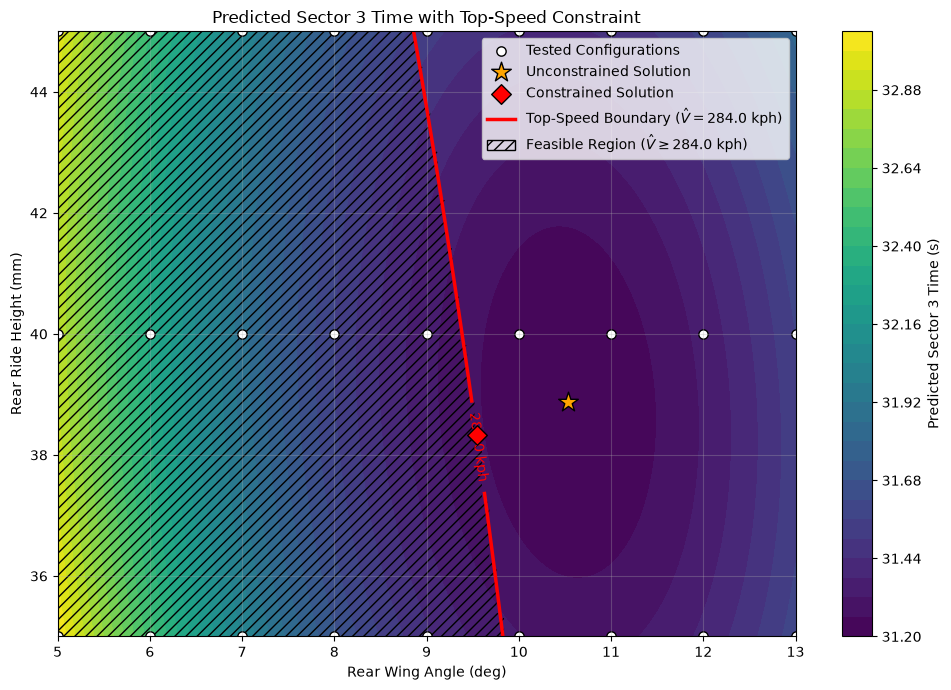

Saved: Aramthun_pr02_constrained.png


In [31]:
print('Task #4')
print('1. Formulate and solve the constrained problem')
print('')

import numpy as np
import scipy.optimize as opt

# 27. Define the minimum top-speed requirement and
#     nonlinear inequality constraint

V_min = 284.0

def top_speed_constraint(x):
    return predict_top_speed(x) - V_min

# 28. Solve the constrained optimization problem
#     using SLSQP

x0_constrained = np.array([
    (wing_bounds[0] + wing_bounds[1]) / 2,
    (ride_height_bounds[0] + ride_height_bounds[1]) / 2
])

bounds = [
    wing_bounds,
    ride_height_bounds
]

constraint = {
    "type": "ineq",
    "fun": top_speed_constraint
}

result_constrained = opt.minimize(
    objective,
    x0_constrained,
    method="SLSQP",
    bounds=bounds,
    constraints=constraint
)

# 29. Report constrained optimization results

x_constrained = result_constrained.x

constrained_wing_angle = x_constrained[0]
constrained_ride_height = x_constrained[1]

constrained_sector_time = predict_sector_time(
    x_constrained
)

constrained_top_speed = predict_top_speed(
    x_constrained
)

constraint_margin = top_speed_constraint(
    x_constrained
)


print("Constrained Optimization Results")
print("--------------------------------")

print("\nOptimizer success:")
print(result_constrained.success)

print("\nOptimizer message:")
print(result_constrained.message)

print("\nRecommended Design:")
print(
    f"Rear wing angle = "
    f"{constrained_wing_angle:.4f} deg"
)

print(
    f"Rear ride height = "
    f"{constrained_ride_height:.4f} mm"
)

print(
    f"\nPredicted Sector 3 time = "
    f"{constrained_sector_time:.4f} s"
)

print(
    f"Predicted top speed = "
    f"{constrained_top_speed:.4f} kph"
)

print(
    f"Constraint margin = "
    f"{constraint_margin:.6f} kph"
)

# 30. Determine whether the top-speed constraint is active

constraint_active = abs(constraint_margin) < 0.05

print("\nTop-speed constraint active:")
print(constraint_active)

if constraint_active:
    print(
        "The top-speed constraint is approximately active "
        "at the recommended design."
    )
else:
    print(
        "The top-speed constraint is not active "
        "at the recommended design."
    )

print('')
print('2. Check sensitivity to the initial guess')
print('')

# 31. Repeat constrained optimization from at least
#     three substantially different initial guesses

initial_guesses = [
    np.array([
        wing_bounds[0] + 0.20 * (wing_bounds[1] - wing_bounds[0]),
        ride_height_bounds[0] + 0.20 * (ride_height_bounds[1] - ride_height_bounds[0])
    ]),
    
    np.array([
        wing_bounds[0] + 0.50 * (wing_bounds[1] - wing_bounds[0]),
        ride_height_bounds[0] + 0.50 * (ride_height_bounds[1] - ride_height_bounds[0])
    ]),
    
    np.array([
        wing_bounds[0] + 0.80 * (wing_bounds[1] - wing_bounds[0]),
        ride_height_bounds[0] + 0.80 * (ride_height_bounds[1] - ride_height_bounds[0])
    ])
]

bounds = [
    wing_bounds,
    ride_height_bounds
]

constraint = {
    "type": "ineq",
    "fun": top_speed_constraint
}


optimization_results = []


for x0 in initial_guesses:

    result = opt.minimize(
        objective,
        x0,
        method="SLSQP",
        bounds=bounds,
        constraints=constraint
    )

    optimal_x = result.x

    sector_time = predict_sector_time(optimal_x)
    top_speed = predict_top_speed(optimal_x)
    constraint_margin = top_speed_constraint(optimal_x)

    optimization_results.append({
        "initial_x1": x0[0],
        "initial_x2": x0[1],
        "optimal_x1": optimal_x[0],
        "optimal_x2": optimal_x[1],
        "sector_time_s": sector_time,
        "top_speed_kph": top_speed,
        "constraint_margin_kph": constraint_margin,
        "success": result.success
    })


df_optimization_runs = pd.DataFrame(
    optimization_results
)

# 32. Display and save optimization runs

print("Optimization Runs:")
display(df_optimization_runs)

df_optimization_runs.to_csv(
    "Aramthun_pr02_optimization_runs.csv",
    index=False
)

print("Saved: Aramthun_pr02_optimization_runs.csv")


x1_spread = (
    df_optimization_runs["optimal_x1"].max()
    - df_optimization_runs["optimal_x1"].min()
)

x2_spread = (
    df_optimization_runs["optimal_x2"].max()
    - df_optimization_runs["optimal_x2"].min()
)

time_spread = (
    df_optimization_runs["sector_time_s"].max()
    - df_optimization_runs["sector_time_s"].min()
)

speed_spread = (
    df_optimization_runs["top_speed_kph"].max()
    - df_optimization_runs["top_speed_kph"].min()
)


print("\nSpread among optimized solutions:")
print(f"Rear wing angle spread = {x1_spread:.6f} deg")
print(f"Rear ride height spread = {x2_spread:.6f} mm")
print(f"Sector 3 time spread = {time_spread:.6f} s")
print(f"Top speed spread = {speed_spread:.6f} kph")


same_candidate = (
    x1_spread < 0.05
    and
    x2_spread < 0.05
    and
    time_spread < 0.01
)

print("\nConverged to essentially the same candidate:")
print(same_candidate)

print('')
print('3. Grid-based feasibility verification')
print('')

# 33. Evaluate predicted top speed on the same design grid
#     and create a feasible mask

top_speed_grid = np.empty_like(
    wing_grid,
    dtype=float
)

for i in range(wing_grid.shape[0]):
    for j in range(wing_grid.shape[1]):

        x = np.array([
            wing_grid[i, j],
            ride_height_grid[i, j]
        ])

        top_speed_grid[i, j] = predict_top_speed(x)


feasible_mask = top_speed_grid >= V_min

print("Number of feasible grid points:")
print(np.sum(feasible_mask))

# 34. Find the best feasible grid point

feasible_sector_time_grid = np.where(
    feasible_mask,
    sector_time_grid,
    np.inf
)

best_feasible_time = np.min(
    feasible_sector_time_grid
)

best_feasible_index = np.argmin(
    feasible_sector_time_grid
)

best_feasible_row, best_feasible_col = np.unravel_index(
    best_feasible_index,
    feasible_sector_time_grid.shape
)

best_feasible_wing = wing_grid[
    best_feasible_row,
    best_feasible_col
]

best_feasible_ride = ride_height_grid[
    best_feasible_row,
    best_feasible_col
]

best_feasible_speed = top_speed_grid[
    best_feasible_row,
    best_feasible_col
]


slsqp_wing = result_constrained.x[0]
slsqp_ride = result_constrained.x[1]

slsqp_time = predict_sector_time(
    result_constrained.x
)

slsqp_speed = predict_top_speed(
    result_constrained.x
)


print("\nBest Feasible Grid Point")
print("------------------------")

print(
    f"Rear wing angle = "
    f"{best_feasible_wing:.4f} deg"
)

print(
    f"Rear ride height = "
    f"{best_feasible_ride:.4f} mm"
)

print(
    f"Predicted Sector 3 time = "
    f"{best_feasible_time:.6f} s"
)

print(
    f"Predicted top speed = "
    f"{best_feasible_speed:.6f} kph"
)


print("\nSLSQP Constrained Solution")
print("--------------------------")

print(
    f"Rear wing angle = "
    f"{slsqp_wing:.4f} deg"
)

print(
    f"Rear ride height = "
    f"{slsqp_ride:.4f} mm"
)

print(
    f"Predicted Sector 3 time = "
    f"{slsqp_time:.6f} s"
)

print(
    f"Predicted top speed = "
    f"{slsqp_speed:.6f} kph"
)

wing_difference = abs(
    best_feasible_wing - slsqp_wing
)

ride_difference = abs(
    best_feasible_ride - slsqp_ride
)

time_difference = abs(
    best_feasible_time - slsqp_time
)

speed_difference = abs(
    best_feasible_speed - slsqp_speed
)


print("\nDifference Between Feasible Grid and SLSQP")
print("------------------------------------------")

print(
    f"Wing angle difference = "
    f"{wing_difference:.6f} deg"
)

print(
    f"Ride height difference = "
    f"{ride_difference:.6f} mm"
)

print(
    f"Sector 3 time difference = "
    f"{time_difference:.6f} s"
)

print(
    f"Top speed difference = "
    f"{speed_difference:.6f} kph"
)

print('')
print('4.Constrained optimization visualization')
print('')

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# 35. Create contour plot of predicted Sector 3 time

fig, ax = plt.subplots(figsize=(10, 7))

contour_time = ax.contourf(
    wing_grid,
    ride_height_grid,
    sector_time_grid,
    levels=30,
    cmap="viridis"
)

cbar = fig.colorbar(contour_time, ax=ax)
cbar.set_label("Predicted Sector 3 Time (s)")

# 36. Overlay top-speed constraint boundary and identify
#     the feasible region

constraint_contour = ax.contour(
    wing_grid,
    ride_height_grid,
    top_speed_grid,
    levels=[V_min],
    colors="red",
    linewidths=2.5
)

ax.clabel(
    constraint_contour,
    fmt={V_min: "284.0 kph"},
    inline=True,
    fontsize=10
)

ax.contourf(
    wing_grid,
    ride_height_grid,
    feasible_mask.astype(int),
    levels=[0.5, 1.5],
    colors="none",
    hatches=["///"]
)

ax.scatter(
    df_grouped["rear_wing_angle_deg"],
    df_grouped["rear_ride_height_mm"],
    marker="o",
    s=45,
    facecolors="white",
    edgecolors="black",
    label="Tested Configurations"
)

ax.scatter(
    result_unconstrained.x[0],
    result_unconstrained.x[1],
    marker="*",
    s=220,
    color="orange",
    edgecolor="black",
    label="Unconstrained Solution",
    zorder=5
)


ax.scatter(
    result_constrained.x[0],
    result_constrained.x[1],
    marker="D",
    s=100,
    color="red",
    edgecolor="black",
    label="Constrained Solution",
    zorder=6
)


ax.set_xlabel("Rear Wing Angle (deg)")
ax.set_ylabel("Rear Ride Height (mm)")

ax.set_title(
    "Predicted Sector 3 Time with Top-Speed Constraint"
)

feasible_patch = Patch(
    facecolor="none",
    edgecolor="black",
    hatch="///",
    label="Feasible Region ($\\hat{V} \\geq 284.0$ kph)"
)

constraint_line = Line2D(
    [0],
    [0],
    color="red",
    linewidth=2.5,
    label="Top-Speed Boundary ($\\hat{V}=284.0$ kph)"
)

handles, labels = ax.get_legend_handles_labels()

handles.extend([
    constraint_line,
    feasible_patch
])

ax.legend(
    handles=handles,
    loc="best"
)

ax.grid(True, alpha=0.3)

plt.tight_layout()

# 37. Save figure

plt.savefig(
    "Aramthun_pr02_constrained.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: Aramthun_pr02_constrained.png")

Task #4 Markdown 

32: The constrained optimization was repeated using three substantially different initial guesses distributed across the tested design region. The optimized rear-wing angle, rear ride height, predicted Sector 3 time, and predicted top speed were then compared across the runs. The solutions converge to essentially the same candidate, with only very small numerical differences between runs. This indicates that the SLSQP solution is not strongly dependent on the selected initial guess and provides confidence that the optimizer is consistently identifying the same constrained optimum within the tested design region. The predicted top speed also remains very close to the 284.0 km/h minimum requirement, indicating that the top-speed constraint is active or nearly active at the optimum.

34: The best feasible grid point should be very close to the SLSQP constrained solution. Small differences are expected because the grid search is limited to discrete points on the 101 × 101 design grid, while SLSQP can search continuously within the tested bounds. If the predicted Sector 3 times and design-variable values are very similar, then the grid search independently confirms that the SLSQP solution is reasonable. The feasible solution should also have a predicted top speed at or just above the 284.0 km/h minimum requirement, indicating that the speed constraint is active or nearly active at the optimum.



Engineering Comparison: 
The unconstrained optimization recommends a rear-wing angle of approximately 10.5373° and a rear ride height of 38.8738 mm, with a predicted Sector 3 time of 31.2106 s and a predicted top speed of 283.2729 km/h. After imposing the minimum top-speed requirement of 284.0 km/h, the constrained solution shifts to approximately 9.5418° rear-wing angle and 38.3276 mm rear ride height. The constrained design has a predicted Sector 3 time of 31.2685 s and a predicted top speed of 284.0000 km/h. Therefore, enforcing the top-speed requirement increases predicted Sector 3 time by approximately 0.0580 s, or about 0.186%, while increasing predicted top speed by approximately 0.7271 km/h. Although the constrained solution is slightly slower through Sector 3, it is a more defensible engineering recommendation because it satisfies the required straight-line performance target while sacrificing only a very small amount of sector-time performance. This provides a better balance between cornering performance and top speed than the unconstrained solution, which fails to meet the 284.0 km/h requirement.

In [33]:
print('Task 5')
print('1. Penalty-function study')
print('')

import numpy as np
import pandas as pd
import scipy.optimize as opt

# 39. Define the penalized objective function

def penalized_objective(x, rho):

    # Predicted Sector 3 time
    sector_time = predict_sector_time(x)

    # Predicted top speed
    top_speed = predict_top_speed(x)

    # Amount by which the speed constraint is violated
    violation = max(0.0, V_min - top_speed)

    # Squared penalty function
    return sector_time + rho * violation**2


# 40. Solve the penalized optimization problem
#     for several values of rho

rho_values = [0.1, 1, 10, 100]

x0_penalty = np.array([
    (wing_bounds[0] + wing_bounds[1]) / 2,
    (ride_height_bounds[0] + ride_height_bounds[1]) / 2
])

bounds = [
    wing_bounds,
    ride_height_bounds
]

penalty_results = []


for rho in rho_values:

    result_penalty = opt.minimize(
        lambda x: penalized_objective(x, rho),
        x0_penalty,
        method="L-BFGS-B",
        bounds=bounds
    )

    x_opt = result_penalty.x

    sector_time = predict_sector_time(x_opt)
    top_speed = predict_top_speed(x_opt)

    violation = max(0.0, V_min - top_speed)

    penalty_value = penalized_objective(
        x_opt,
        rho
    )

    penalty_results.append({
        "rho": rho,
        "rear_wing_angle_deg": x_opt[0],
        "rear_ride_height_mm": x_opt[1],
        "sector_time_s": sector_time,
        "top_speed_kph": top_speed,
        "violation_kph": violation,
        "penalized_objective": penalty_value
    })


# 41. Store results in df_penalty

df_penalty = pd.DataFrame(
    penalty_results
)


# 42. Display and save results

print("Penalty Method Results:")
display(df_penalty)

df_penalty.to_csv(
    "Aramthun_pr02_penalty.csv",
    index=False
)

print("Saved: Aramthun_pr02_penalty.csv")


large_penalty_solution = df_penalty.loc[
    df_penalty["rho"].idxmax()
]

print("\nLarge-Penalty Solution (rho = 100)")
print("----------------------------------")

print(
    f"Rear wing angle = "
    f"{large_penalty_solution['rear_wing_angle_deg']:.4f} deg"
)

print(
    f"Rear ride height = "
    f"{large_penalty_solution['rear_ride_height_mm']:.4f} mm"
)

print(
    f"Sector 3 time = "
    f"{large_penalty_solution['sector_time_s']:.6f} s"
)

print(
    f"Top speed = "
    f"{large_penalty_solution['top_speed_kph']:.6f} kph"
)

print(
    f"Constraint violation = "
    f"{large_penalty_solution['violation_kph']:.6f} kph"
)


print("\nExplicit SLSQP Constrained Solution")
print("-----------------------------------")

print(
    f"Rear wing angle = "
    f"{result_constrained.x[0]:.4f} deg"
)

print(
    f"Rear ride height = "
    f"{result_constrained.x[1]:.4f} mm"
)

print(
    f"Sector 3 time = "
    f"{predict_sector_time(result_constrained.x):.6f} s"
)

print(
    f"Top speed = "
    f"{predict_top_speed(result_constrained.x):.6f} kph"
)

print('')
print('2. Final engineering recommendation')
print('')

# 44. Create summary DataFrame of the four key solutions

x_unconstrained = result_unconstrained.x
time_unconstrained = predict_sector_time(x_unconstrained)
speed_unconstrained = predict_top_speed(x_unconstrained)

x_constrained = result_constrained.x
time_constrained = predict_sector_time(x_constrained)
speed_constrained = predict_top_speed(x_constrained)

x_feasible_grid = np.array([
    best_feasible_wing,
    best_feasible_ride
])

time_feasible_grid = best_feasible_time
speed_feasible_grid = best_feasible_speed

# rho = 100 penalty solution
penalty_100 = df_penalty.loc[
    np.isclose(df_penalty["rho"], 100)
].iloc[0]

x_penalty_100 = np.array([
    penalty_100["rear_wing_angle_deg"],
    penalty_100["rear_ride_height_mm"]
])

time_penalty_100 = penalty_100["sector_time_s"]
speed_penalty_100 = penalty_100["top_speed_kph"]

feasibility_tolerance = 1e-6

df_recommendation = pd.DataFrame({
    "solution": [
        "Unconstrained",
        "Constrained SLSQP",
        "Best Feasible Grid",
        "Penalty rho=100"
    ],

    "rear_wing_angle_deg": [
        x_unconstrained[0],
        x_constrained[0],
        x_feasible_grid[0],
        x_penalty_100[0]
    ],

    "rear_ride_height_mm": [
        x_unconstrained[1],
        x_constrained[1],
        x_feasible_grid[1],
        x_penalty_100[1]
    ],

    "sector_time_s": [
        time_unconstrained,
        time_constrained,
        time_feasible_grid,
        time_penalty_100
    ],

    "top_speed_kph": [
        speed_unconstrained,
        speed_constrained,
        speed_feasible_grid,
        speed_penalty_100
    ]
})

df_recommendation["feasibility_status"] = np.where(
    df_recommendation["top_speed_kph"]
    >= V_min - feasibility_tolerance,
    "Feasible",
    "Infeasible"
)

print("Recommendation Summary:")
display(df_recommendation)

df_recommendation.to_csv(
    "Aramthun_pr02_recommendation.csv",
    index=False
)

print("Saved: Aramthun_pr02_recommendation.csv")

# 45. Select final model-based recommended candidate

final_recommended_x = result_constrained.x

final_wing_angle = final_recommended_x[0]
final_ride_height = final_recommended_x[1]

final_sector_time = predict_sector_time(
    final_recommended_x
)

final_top_speed = predict_top_speed(
    final_recommended_x
)

final_constraint_margin = (
    final_top_speed - V_min
)


print("\nFinal Recommended Model-Based Setup")
print("-----------------------------------")

print(
    f"Rear wing angle = "
    f"{final_wing_angle:.4f} deg"
)

print(
    f"Rear ride height = "
    f"{final_ride_height:.4f} mm"
)

print(
    f"Predicted Sector 3 time = "
    f"{final_sector_time:.4f} s"
)

print(
    f"Predicted top speed = "
    f"{final_top_speed:.4f} kph"
)

print(
    f"Constraint margin = "
    f"{final_constraint_margin:.6f} kph"
)

print(
    "Feasibility =",
    "Feasible"
    if final_top_speed >= V_min - feasibility_tolerance
    else "Infeasible"
)

Task 5
1. Penalty-function study

Penalty Method Results:


,rho,rear_wing_angle_deg,rear_ride_height_mm,sector_time_s,top_speed_kph,violation_kph,penalized_objective
0,0.1,10.062886,38.624159,31.223685,283.621020,0.378980,31.238047
1,1.0,9.641824,38.386124,31.257452,283.927561,0.072439,31.262699
2,10.0,9.552860,38.334115,31.267266,283.992016,0.007984,31.267903
3,100.0,9.542946,38.328270,31.268418,283.999194,0.000806,31.268483


Saved: Aramthun_pr02_penalty.csv

Large-Penalty Solution (rho = 100)
----------------------------------
Rear wing angle = 9.5429 deg
Rear ride height = 38.3283 mm
Sector 3 time = 31.268418 s
Top speed = 283.999194 kph
Constraint violation = 0.000806 kph

Explicit SLSQP Constrained Solution
-----------------------------------
Rear wing angle = 9.5418 deg
Rear ride height = 38.3277 mm
Sector 3 time = 31.268548 s
Top speed = 284.000000 kph

2. Final engineering recommendation

Recommendation Summary:


,solution,rear_wing_angle_deg,rear_ride_height_mm,sector_time_s,top_speed_kph,feasibility_status
0,Unconstrained,10.537272,38.873862,31.210568,283.272864,Infeasible
1,Constrained SLSQP,9.541827,38.327667,31.268548,284.000000,Feasible
2,Best Feasible Grid,9.560000,38.100000,31.269140,284.001706,Feasible
3,Penalty rho=100,9.542946,38.328270,31.268418,283.999194,Infeasible


Saved: Aramthun_pr02_recommendation.csv

Final Recommended Model-Based Setup
-----------------------------------
Rear wing angle = 9.5418 deg
Rear ride height = 38.3277 mm
Predicted Sector 3 time = 31.2685 s
Predicted top speed = 284.0000 kph
Constraint margin = -0.000000 kph
Feasibility = Feasible


Question #45 Markdown: 
The constrained SLSQP solution is selected as the final model-based setup. It is preferable because it directly satisfies the required minimum predicted top speed of 284.0 km/h while minimizing predicted Sector 3 time within the tested design region. The best feasible grid point independently produces a very similar solution, supporting the numerical optimizer result. In addition, the repeated SLSQP runs from substantially different initial guesses converge to essentially the same candidate, indicating that the recommendation is not strongly dependent on the starting point. The validation results for both quadratic response surfaces also showed strong predictive performance on unseen setup configurations, providing reasonable confidence in using the models for this optimization exercise.

Question #46 Markdown: 
The constrained SLSQP candidate is preferable to the unconstrained minimum because the unconstrained solution achieves a slightly lower predicted Sector 3 time only by allowing predicted top speed to fall below the required 284.0 km/h minimum. The constrained recommendation sacrifices only a small amount of Sector 3 performance while satisfying the straight-line-speed requirement, making it a more balanced and defensible engineering choice.

The top-speed constraint is active, or approximately active, at the recommended setup because the predicted top speed is essentially 284.0 km/h and the constraint margin is very close to zero. Physically, this means the optimizer would prefer to move farther toward a setup that improves Sector 3 time, but doing so would reduce top speed below the acceptable limit. Therefore, the speed requirement is directly determining the final compromise between cornering performance and straight-line speed.

The numerical optimizer and the grid-based verification support the same conclusion. The best feasible grid point is very close to the SLSQP constrained solution, with the small difference expected because the grid is limited to discrete design points while SLSQP searches continuously. The repeated constrained optimizations from different initial guesses also converge to essentially the same candidate, which further supports the stability of the recommendation.

The penalty-method results show that feasibility improves as the penalty parameter rho increases. With a small penalty, the optimizer is willing to accept a noticeable top-speed violation in exchange for a faster predicted Sector 3 time. As rho increases, violating the speed requirement becomes increasingly expensive, causing the recommended design to move toward the explicitly constrained SLSQP solution. The rho = 100 result should therefore be close to the constrained optimum, although the explicit SLSQP formulation is preferable because it directly enforces the engineering requirement instead of depending on the selected penalty magnitude.

The recommended setup is still not a confirmed physical optimum because it is based on quadratic surrogate models fitted to a limited set of experimental configurations. Model error, measurement noise, environmental conditions, tire behavior, aerodynamic interactions, and other vehicle dynamics effects may not be fully represented by the response surfaces. The models should also not be assumed to remain accurate outside the tested design region. Optimization therefore provides a strong candidate for further testing rather than unquestionable proof of the true vehicle optimum.

Additional track testing should be performed near the recommended rear-wing angle and rear ride height, including the predicted optimum and several nearby configurations on both sides of the top-speed constraint. Repeated laps should be collected to determine whether the predicted differences are larger than normal lap-to-lap variation. Higher-fidelity aerodynamic or vehicle-dynamics simulation could also be used to evaluate the candidate under a wider range of operating conditions. If the measured Sector 3 time and top speed agree closely with the model predictions, the recommendation can then be accepted with greater confidence.